# 06. Feature Selection
## 주요 센서 변수 선별

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

SECOM 데이터는 전처리 이후에도 442개의 센서 변수를 포함하고 있는
고차원 데이터이다.

이전 단계에서 SMOTE를 이용하여 클래스 불균형을 완화하였으나,
SMOTE 1:1 적용만으로는 Fail Recall과 False Negative가 개선되지 않았다.

따라서 본 Notebook에서는 불량 예측에 상대적으로 유용한 센서 변수를
선별하여 데이터 차원을 줄이고 모델이 핵심 패턴에 집중할 수 있도록 한다.

본 단계에서는 Mutual Information 기반 SelectKBest를 사용하여
여러 Feature 개수를 비교한다.

### 주요 분석 목표

1. Feature Selection을 Training Data 내부에서만 수행한다.
2. 여러 Feature 개수(k)를 Cross Validation으로 비교한다.
3. PR-AUC를 주요 기준으로 최적 Feature 개수를 선택한다.
4. 선택된 센서 Feature 목록을 확인한다.
5. Feature Selection 전후의 모델 성능을 비교한다.
6. Test Data는 Feature 개수 결정에 사용하지 않는다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from functools import partial

from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

set_config(display="text")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. 데이터 준비

이전 단계와 동일한 데이터 분할 조건을 사용한다.

- Test Size: 20%
- `random_state=42`
- `stratify=y`

Feature Selection에 사용할 Feature 개수와 선택 기준은
Test Data를 사용하지 않고 Training Data 내부의
Cross Validation 결과만을 이용하여 결정한다.

이를 통해 Test Data의 성능을 보고 Feature 개수를 선택하는
Data Leakage를 방지한다.

In [3]:
DATA_PATH = Path(
    "../data/processed/uci-secom.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (1567, 592)


In [4]:
feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

X = df[feature_cols].copy()

y = (
    df["Pass/Fail"]
    .replace({
        -1: 0,
        1: 1
    })
    .astype(int)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(
    y.value_counts()
    .sort_index()
)

X shape: (1567, 590)
y shape: (1567,)

Target distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print(
    f"\nTrain Fail Rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Test Fail Rate : "
    f"{y_test.mean() * 100:.2f}%"
)

X_train: (1253, 590)
X_test : (314, 590)

Train Fail Rate: 6.62%
Test Fail Rate : 6.69%


## 2. Cross Validation 내부 Feature 품질 필터

이전 전처리에서는 전체 Training Data를 기준으로
고결측 및 비정보 Feature를 식별하였다.

본 단계에서는 Cross Validation 과정에서도
Validation Fold의 정보가 Feature 제거 기준에 포함되지 않도록
Feature 품질 필터를 Pipeline 내부에 포함한다.

각 Training Fold에서 다음 기준을 새롭게 계산한다.

1. 결측률 40% 이상
2. 모든 값이 결측
3. 하나의 값만 가지는 변수

선정된 Feature 제거 기준은 동일 Fold의 Validation Data에 그대로 적용한다.

In [6]:
class FeatureQualityFilter(
    BaseEstimator,
    TransformerMixin
):
    def __init__(
        self,
        missing_threshold=40.0
    ):
        self.missing_threshold = (
            missing_threshold
        )

    def fit(self, X, y=None):

        X = pd.DataFrame(X).copy()

        missing_ratio = (
            X.isna()
            .mean()
            .mul(100)
        )

        high_missing = (
            missing_ratio[
                missing_ratio
                >= self.missing_threshold
            ]
            .index
            .tolist()
        )

        all_missing = [
            col for col in X.columns
            if X[col].isna().all()
        ]

        single_value = [
            col for col in X.columns
            if X[col].nunique(
                dropna=True
            ) == 1
        ]

        self.features_to_remove_ = sorted(
            set(
                high_missing
                + all_missing
                + single_value
            )
        )

        self.features_to_keep_ = [
            col for col in X.columns
            if col
            not in self.features_to_remove_
        ]

        self.feature_names_in_ = np.array(
            X.columns,
            dtype=object
        )

        return self

    def transform(self, X):

        X = pd.DataFrame(
            X,
            columns=self.feature_names_in_
        ).copy()

        return X[
            self.features_to_keep_
        ]

    def get_feature_names_out(
        self,
        input_features=None
    ):
        return np.array(
            self.features_to_keep_,
            dtype=object
        )

In [7]:
quality_filter_preview = (
    FeatureQualityFilter(
        missing_threshold=40
    )
)

quality_filter_preview.fit(
    X_train
)

print(
    "Original features:",
    X_train.shape[1]
)

print(
    "Features removed:",
    len(
        quality_filter_preview
        .features_to_remove_
    )
)

print(
    "Features retained:",
    len(
        quality_filter_preview
        .features_to_keep_
    )
)

Original features: 590
Features removed: 148
Features retained: 442


## 3. Mutual Information 기반 Feature Selection

전처리 후 유지된 센서 변수 중 Fail 여부와 상대적으로
높은 의존 관계를 보이는 Feature를 선별한다.

본 프로젝트에서는 Mutual Information(MI)을 사용한다.

MI 값이 높을수록 해당 Feature와 Fail 여부 사이에
더 많은 통계적 의존 정보가 존재한다고 해석할 수 있다.

다만 MI 역시 각 Feature를 개별적으로 평가하는 방식이므로,
여러 Feature 간 복잡한 상호작용이나 물리적인 인과관계를
직접 의미하지는 않는다.

따라서 선택된 Feature를 반도체 불량의 Root Cause라고
해석하지 않고 모델링에 유용한 후보 변수로 해석한다.

In [8]:
def mutual_info_score_func(
    X,
    y
):
    return mutual_info_classif(
        X,
        y,
        random_state=42
    )

## 4. Feature 개수 후보 비교

Feature Selection의 효과를 확인하기 위해 다음 후보를 비교한다.

- Top 25
- Top 50
- Top 100
- Top 200
- All Features

최적 Feature 개수는 Test Data 성능을 기준으로 결정하지 않는다.

Training Data에 대해 5-Fold Stratified Cross Validation을 수행하고,
평균 PR-AUC를 주요 기준으로 Feature 개수를 결정한다.

Fail 검출이 중요한 문제이므로 Recall과 F2-score도 함께 확인한다.

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [10]:
f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": f2_scorer,
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc"
}

In [11]:
k_candidates = [
    25,
    50,
    100,
    200,
    "all"
]

In [12]:
cv_results_list = []

for k in k_candidates:

    pipeline = Pipeline([
        (
            "quality_filter",
            FeatureQualityFilter(
                missing_threshold=40
            )
        ),
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "selector",
            SelectKBest(
                score_func=
                mutual_info_score_func,
                k=k
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                random_state=42
            )
        )
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=None,
        return_train_score=False
    )

    cv_results_list.append({
        "k": k,

        "Accuracy":
            scores[
                "test_accuracy"
            ].mean(),

        "Precision":
            scores[
                "test_precision"
            ].mean(),

        "Recall":
            scores[
                "test_recall"
            ].mean(),

        "F1":
            scores[
                "test_f1"
            ].mean(),

        "F2":
            scores[
                "test_f2"
            ].mean(),

        "PR-AUC":
            scores[
                "test_pr_auc"
            ].mean(),

        "ROC-AUC":
            scores[
                "test_roc_auc"
            ].mean()
    })

    print(
        f"Completed k={k}"
    )

C:\Users\ark34\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ark34\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ark34\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

Completed k=25
Completed k=50
Completed k=100
Completed k=200
Completed k=all


In [13]:
cv_results_df = pd.DataFrame(
    cv_results_list
)

cv_results_df.round(4)

,k,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC
0,25,0.9346,0.2000,0.0118,0.0222,0.0145,0.1445,0.6054
1,50,0.9298,0.1000,0.0118,0.0211,0.0143,0.1302,0.6160
2,100,0.9162,0.1649,0.0721,0.0976,0.0803,0.1521,0.6463
3,200,0.8938,0.1592,0.1316,0.1414,0.1349,0.1475,0.6528
4,all,0.8763,0.1618,0.2169,0.1825,0.2007,0.1642,0.6223


In [32]:
CV_RESULT_PATH = Path(
    "../results/metrics/"
    "feature_selection_cv_results.csv"
)

cv_results_df.to_csv(
    CV_RESULT_PATH,
    index=False
)

print(
    "Saved to:",
    CV_RESULT_PATH
)

print(
    "File exists:",
    CV_RESULT_PATH.exists()
)

Saved to: ..\results\metrics\feature_selection_cv_results.csv
File exists: True


In [14]:
cv_results_sorted = (
    cv_results_df
    .sort_values(
        "PR-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

cv_results_sorted.round(4)

,k,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC
0,all,0.8763,0.1618,0.2169,0.1825,0.2007,0.1642,0.6223
1,100,0.9162,0.1649,0.0721,0.0976,0.0803,0.1521,0.6463
2,200,0.8938,0.1592,0.1316,0.1414,0.1349,0.1475,0.6528
3,25,0.9346,0.2000,0.0118,0.0222,0.0145,0.1445,0.6054
4,50,0.9298,0.1000,0.0118,0.0211,0.0143,0.1302,0.6160


## 5. Feature 개수별 Cross Validation 성능 비교

Feature 수를 감소시켰을 때 성능이 반드시 향상되는 것은 아니다.

Feature를 지나치게 많이 유지하면 노이즈와 불필요한 변수가
모델 학습을 방해할 수 있는 반면,

Feature를 지나치게 적게 선택하면 Fail 예측에 필요한
정보가 손실될 수 있다.

따라서 여러 Feature 개수를 비교하여
모델 성능과 데이터 차원의 균형을 확인한다.

In [15]:
plot_df = (
    cv_results_df
    .copy()
)

plot_df["k_label"] = (
    plot_df["k"]
    .astype(str)
)

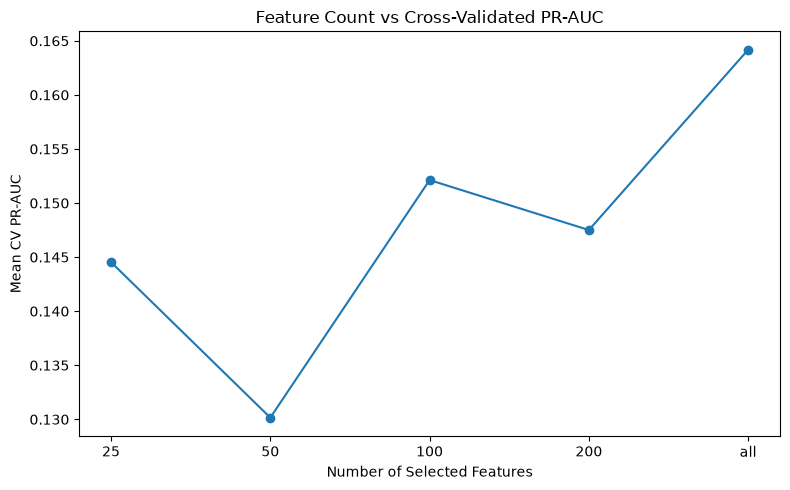

Saved to: ..\results\figures\feature_count_vs_pr_auc.png


In [16]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    plot_df["k_label"],
    plot_df["PR-AUC"],
    marker="o"
)

plt.xlabel(
    "Number of Selected Features"
)

plt.ylabel(
    "Mean CV PR-AUC"
)

plt.title(
    "Feature Count vs Cross-Validated PR-AUC"
)

plt.tight_layout()

FEATURE_COUNT_PATH = Path(
    "../results/figures/"
    "feature_count_vs_pr_auc.png"
)

plt.savefig(
    FEATURE_COUNT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved to:",
    FEATURE_COUNT_PATH
)

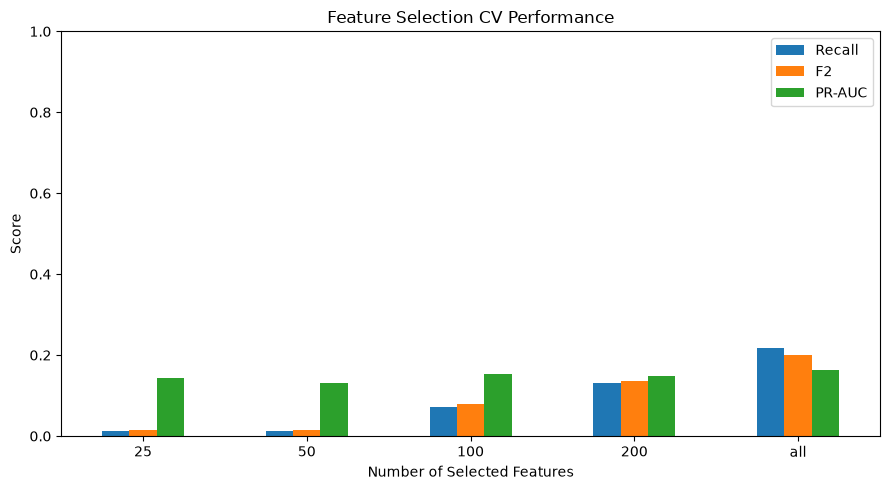

In [17]:
plot_df.set_index(
    "k_label"
)[
    [
        "Recall",
        "F2",
        "PR-AUC"
    ]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel(
    "Number of Selected Features"
)

plt.ylabel("Score")

plt.title(
    "Feature Selection CV Performance"
)

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()

FEATURE_METRICS_PATH = Path(
    "../results/figures/"
    "feature_selection_cv_metrics.png"
)

plt.savefig(
    FEATURE_METRICS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
best_row = (
    cv_results_df
    .sort_values(
        "PR-AUC",
        ascending=False
    )
    .iloc[0]
)

best_k = best_row["k"]

print(
    "Best k based on CV PR-AUC:",
    best_k
)

print(
    f"Best CV PR-AUC: "
    f"{best_row['PR-AUC']:.4f}"
)

print(
    f"Corresponding Recall: "
    f"{best_row['Recall']:.4f}"
)

print(
    f"Corresponding F2: "
    f"{best_row['F2']:.4f}"
)

Best k based on CV PR-AUC: all
Best CV PR-AUC: 0.1642
Corresponding Recall: 0.2169
Corresponding F2: 0.2007


## 6. 최종 Feature Selection 모델 학습

Cross Validation 결과를 이용하여 최적 Feature 개수를 결정한 후,
전체 Training Data를 이용하여 Feature Selection Pipeline을 다시 학습한다.

이 단계에서도 Test Data는 Feature 선택 과정에 사용되지 않는다.

학습이 완료된 후 최종적으로 선택된 센서 변수의 이름과
Mutual Information Score를 확인한다.

In [19]:
best_pipeline = Pipeline([
    (
        "quality_filter",
        FeatureQualityFilter(
            missing_threshold=40
        )
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "selector",
        SelectKBest(
            score_func=
            mutual_info_score_func,
            k=best_k
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

best_pipeline.fit(
    X_train,
    y_train
)

print(
    "Final feature-selection "
    "pipeline fitted."
)

Final feature-selection pipeline fitted.


In [20]:
quality_filter = (
    best_pipeline
    .named_steps[
        "quality_filter"
    ]
)

selector = (
    best_pipeline
    .named_steps[
        "selector"
    ]
)

filtered_feature_names = (
    quality_filter
    .get_feature_names_out()
)

selected_mask = (
    selector.get_support()
)

selected_feature_names = (
    filtered_feature_names[
        selected_mask
    ]
)

print(
    "Features after quality filtering:",
    len(filtered_feature_names)
)

print(
    "Selected features:",
    len(selected_feature_names)
)

Features after quality filtering: 442
Selected features: 442


In [21]:
selected_feature_names

array(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10',
       'feature_11', 'feature_12', 'feature_14', 'feature_15',
       'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'feature_20', 'feature_21', 'feature_22', 'feature_23',
       'feature_24', 'feature_25', 'feature_26', 'feature_27',
       'feature_28', 'feature_29', 'feature_30', 'feature_31',
       'feature_32', 'feature_33', 'feature_34', 'feature_35',
       'feature_36', 'feature_37', 'feature_38', 'feature_39',
       'feature_40', 'feature_41', 'feature_43', 'feature_44',
       'feature_45', 'feature_46', 'feature_47', 'feature_48',
       'feature_50', 'feature_51', 'feature_53', 'feature_54',
       'feature_55', 'feature_56', 'feature_57', 'feature_58',
       'feature_59', 'feature_60', 'feature_61', 'feature_62',
       'feature_63', 'feature_64', 'feature_65', 'feature_66',
       'feature_67', 'feature_68', '

In [22]:
mi_scores = (
    selector.scores_
)

feature_score_df = pd.DataFrame({
    "Feature":
        filtered_feature_names,

    "MI Score":
        mi_scores
})

feature_score_df = (
    feature_score_df
    .sort_values(
        "MI Score",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_score_df.head(20)

,Feature,MI Score
0,feature_411,0.039572
1,feature_588,0.027671
2,feature_541,0.026249
3,feature_128,0.025875
4,feature_274,0.025693
5,feature_406,0.025579
6,feature_267,0.024896
7,feature_443,0.024705
8,feature_138,0.024174
9,feature_577,0.023668


In [23]:
selected_feature_df = (
    feature_score_df[
        feature_score_df[
            "Feature"
        ].isin(
            selected_feature_names
        )
    ]
    .sort_values(
        "MI Score",
        ascending=False
    )
    .reset_index(drop=True)
)

selected_feature_df.head(20)

,Feature,MI Score
0,feature_411,0.039572
1,feature_588,0.027671
2,feature_541,0.026249
3,feature_128,0.025875
4,feature_274,0.025693
5,feature_406,0.025579
6,feature_267,0.024896
7,feature_443,0.024705
8,feature_138,0.024174
9,feature_577,0.023668


In [24]:
SELECTED_FEATURE_PATH = Path(
    "../results/metrics/"
    "selected_features.csv"
)

selected_feature_df.to_csv(
    SELECTED_FEATURE_PATH,
    index=False
)

print(
    "Saved to:",
    SELECTED_FEATURE_PATH
)

Saved to: ..\results\metrics\selected_features.csv


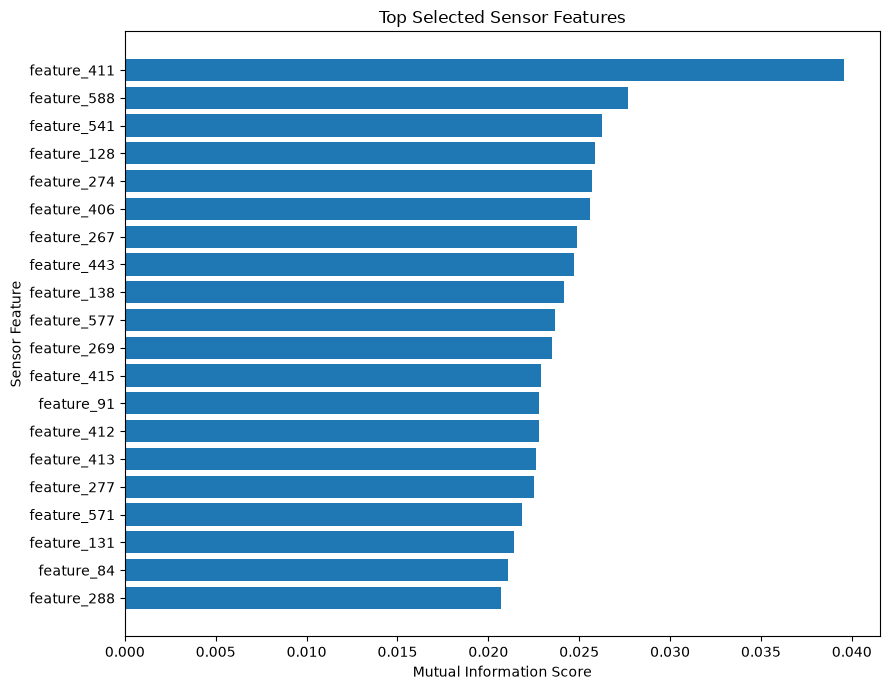

In [25]:
top_features_plot = (
    selected_feature_df
    .head(20)
    .sort_values(
        "MI Score",
        ascending=True
    )
)

plt.figure(
    figsize=(9, 7)
)

plt.barh(
    top_features_plot["Feature"],
    top_features_plot["MI Score"]
)

plt.xlabel(
    "Mutual Information Score"
)

plt.ylabel(
    "Sensor Feature"
)

plt.title(
    "Top Selected Sensor Features"
)

plt.tight_layout()

SELECTED_FEATURE_FIGURE = Path(
    "../results/figures/"
    "top_selected_features.png"
)

plt.savefig(
    SELECTED_FEATURE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
selected_pred = (
    best_pipeline.predict(
        X_test
    )
)

selected_prob = (
    best_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

In [27]:
selected_accuracy = accuracy_score(
    y_test,
    selected_pred
)

selected_precision = precision_score(
    y_test,
    selected_pred,
    zero_division=0
)

selected_recall = recall_score(
    y_test,
    selected_pred,
    zero_division=0
)

selected_f1 = f1_score(
    y_test,
    selected_pred,
    zero_division=0
)

selected_f2 = fbeta_score(
    y_test,
    selected_pred,
    beta=2,
    zero_division=0
)

selected_pr_auc = average_precision_score(
    y_test,
    selected_prob
)

selected_roc_auc = roc_auc_score(
    y_test,
    selected_prob
)

print(
    f"Accuracy  : "
    f"{selected_accuracy:.4f}"
)

print(
    f"Precision : "
    f"{selected_precision:.4f}"
)

print(
    f"Recall    : "
    f"{selected_recall:.4f}"
)

print(
    f"F1-score  : "
    f"{selected_f1:.4f}"
)

print(
    f"F2-score  : "
    f"{selected_f2:.4f}"
)

print(
    f"PR-AUC    : "
    f"{selected_pr_auc:.4f}"
)

print(
    f"ROC-AUC   : "
    f"{selected_roc_auc:.4f}"
)

Accuracy  : 0.8758
Precision : 0.1250
Recall    : 0.1429
F1-score  : 0.1333
F2-score  : 0.1389
PR-AUC    : 0.1190
ROC-AUC   : 0.6205


In [28]:
selected_cm = confusion_matrix(
    y_test,
    selected_pred
)

print(selected_cm)

[[272  21]
 [ 18   3]]


In [31]:
if best_k == "all":
    model_name = (
        f"Logistic Regression + MI "
        f"(All {len(selected_feature_names)} Features)"
    )
else:
    model_name = (
        f"Logistic Regression + MI Top-{best_k}"
    )

feature_selection_result = pd.DataFrame({
    "Model": [
        model_name
    ],

    "Selected Features": [
        len(selected_feature_names)
    ],

    "Accuracy": [
        selected_accuracy
    ],

    "Precision": [
        selected_precision
    ],

    "Recall": [
        selected_recall
    ],

    "F1": [
        selected_f1
    ],

    "F2": [
        selected_f2
    ],

    "PR-AUC": [
        selected_pr_auc
    ],

    "ROC-AUC": [
        selected_roc_auc
    ],

    "False Negatives": [
        selected_fn
    ],

    "True Positives": [
        selected_tp
    ]
})

feature_selection_result.round(4)

,Model,Selected Features,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,False Negatives,True Positives
0,Logistic Regression + MI (All 442 Features),442,0.8758,0.125,0.1429,0.1333,0.1389,0.119,0.6205,18,3


In [30]:
FEATURE_SELECTION_RESULT_PATH = Path(
    "../results/metrics/"
    "feature_selection_results.csv"
)

feature_selection_result.to_csv(
    FEATURE_SELECTION_RESULT_PATH,
    index=False
)

print(
    "Saved to:",
    FEATURE_SELECTION_RESULT_PATH
)

Saved to: ..\results\metrics\feature_selection_results.csv


## 7. Feature Selection 결과 평가

Mutual Information 기반 SelectKBest를 이용하여
여러 Feature 개수를 비교하였다.

Feature 개수는 Test Data의 성능을 보고 결정하지 않고,
Training Data 내부의 5-Fold Stratified Cross Validation에서
측정한 PR-AUC를 주요 기준으로 선택하였다.

본 실험에서는 단순히 Feature 수를 줄이는 것 자체가 목적이 아니라,
불필요한 센서 정보를 제거하면서 Fail 예측에 필요한 정보를
최대한 유지할 수 있는 Feature 수를 탐색한다.

최종 결과는 다음 항목을 중심으로 평가한다.

- 선택된 Feature 개수
- Cross-Validated PR-AUC
- Fail Recall
- F2-score
- False Negative
- Test PR-AUC

선택된 Feature는 예측 모델링 관점에서 상대적으로 유용한 변수이며,
실제 공정의 물리적 Root Cause를 의미하지 않는다.

## 7. Feature Selection 종합 결과

본 단계에서는 전처리 후 유지된 442개의 센서 변수를 대상으로
Mutual Information 기반 SelectKBest를 적용하여
Feature 수 감소가 Fail 예측 성능에 미치는 영향을 분석하였다.

Feature 개수는 Test Data의 성능을 이용하여 결정하지 않고,
Training Data 내부의 5-Fold Stratified Cross Validation에서
측정한 PR-AUC를 주요 기준으로 선택하였다.


### 1. Feature 개수별 Cross Validation 결과

다음 Feature 개수를 비교하였다.

- Top 25
- Top 50
- Top 100
- Top 200
- All Features (442개)

Cross Validation 결과 PR-AUC는 다음과 같이 나타났다.

- Top 25: 0.1445
- Top 50: 0.1302
- Top 100: 0.1521
- Top 200: 0.1475
- All Features: **0.1642**

따라서 사전에 설정한 PR-AUC 기준에서
442개의 Feature를 모두 사용하는 경우가 가장 높은 성능을 보였다.

All Features 조건에서는 다음과 같은 평균 Cross Validation 성능을 기록하였다.

- Recall: **0.2169**
- F2-score: **0.2007**
- PR-AUC: **0.1642**
- ROC-AUC: **0.6223**


### 2. Feature 수 감소에 따른 영향

Feature 수를 감소시키는 것이 반드시 성능 향상으로 이어지지는 않았다.

특히 Top 25와 Top 50만을 사용하는 경우
Fail Recall이 약 0.0118까지 크게 감소하였다.

Top 100과 Top 200에서는 일부 성능이 회복되었지만,
주요 평가 지표인 PR-AUC에서는 전체 442개 Feature를 사용하는 경우보다
낮은 성능을 보였다.

따라서 현재 데이터에서는 Fail 예측에 필요한 정보가
소수의 개별 센서 변수에만 집중되어 있기보다
여러 센서 변수에 분산되어 있을 가능성을 고려할 수 있다.


### 3. 최종 Test 성능

Cross Validation 결과에 따라 최종 Feature 개수는
All Features(442개)로 결정하였다.

최종 Test Data에서의 성능은 다음과 같다.

- Accuracy: **87.58%**
- Precision: **12.50%**
- Recall: **14.29%**
- F1-score: **13.33%**
- F2-score: **13.89%**
- PR-AUC: **0.1190**
- ROC-AUC: **0.6205**

Confusion Matrix는 다음과 같다.

- True Negative: 272개
- False Positive: 21개
- False Negative: 18개
- True Positive: 3개

실제 Fail 샘플 21개 중 3개만 검출하였으며,
18개의 Fail 샘플을 여전히 Pass로 판단하였다.


### 4. Baseline과의 비교

최종 Feature Selection 모델은
Baseline Logistic Regression과 동일한 Test 성능을 보였다.

이는 Cross Validation 과정에서 최적 Feature 개수로
`all`이 선택되어 품질 필터 이후의 442개 센서 변수를
모두 유지했기 때문이다.

따라서 Mutual Information 기반 단변량 Feature Selection은
현재 Logistic Regression 모델에서 추가적인 성능 향상을 제공하지 않았다.


### 5. 결과 해석

본 실험 결과는 Feature Selection 자체가 불필요하다는 것을 의미하지 않는다.

Mutual Information 기반 SelectKBest는 각 Feature와 Target 간의
관계를 개별적으로 평가하는 단변량 Feature Selection 방법이다.

따라서 여러 센서 변수 간의 상호작용이나 비선형적인 관계가
Fail 예측에 중요한 경우 이러한 정보를 충분히 반영하지 못할 수 있다.

이번 실험에서는 다음과 같이 해석한다.

**현재 SECOM 데이터에서 Mutual Information 기반 단변량 Feature Selection과
Logistic Regression의 조합은 442개 Feature를 추가적으로 축소했을 때
Fail 예측 성능의 개선을 보이지 않았다.**

그러나 MI Score를 이용한 Feature Ranking 자체는
상대적으로 Fail과 높은 의존성을 보이는 센서 변수를 탐색하는
보조적인 분석 자료로 활용할 수 있다.


## 다음 단계: 비선형 모델 적용

지금까지 사용한 Logistic Regression은 선형적인 결정 경계를 기반으로 한다.

반면 SECOM의 반도체 공정 데이터에서는 여러 센서 변수 간의
비선형 관계와 Feature Interaction이 Fail 발생에 영향을 줄 가능성이 있다.

따라서 다음 단계에서는 Tree 기반 Boosting 모델인 XGBoost를 적용하여
비선형 패턴과 Feature Interaction을 학습한다.

또한 심각한 클래스 불균형을 고려하기 위해
XGBoost의 `scale_pos_weight`를 이용한 불균형 보정 효과도 비교한다.

다음 단계에서는 다음 모델을 비교한다.

1. 기본 XGBoost
2. `scale_pos_weight`를 적용한 XGBoost
3. 성능 및 False Negative 비교
4. Feature Importance 분석